# Autoencoder with a self supervised pretrained ViT as feature extractor.


In [ ]:
import torch 
import torch.nn.functional as F

import timm  # pip install timm
import numpy as np
from torchvision.transforms import v2
from tqdm import tqdm
import numpy as np

from utils import build_dataloader, WebotsFrameDataset, set_seed
from attention_model.conv_encoder import ConvEncoder


print(f'PyTorch version: {torch.__version__}')
print('Numpy version:', np.__version__)

seed = 42
set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.12.0+cu130
Numpy version: 2.4.6


#### List all DiNO pretrained ViT models here:

In [2]:
print(timm.list_models("*dino*", pretrained=True))

['convnext_base.dinov3_lvd1689m', 'convnext_large.dinov3_lvd1689m', 'convnext_small.dinov3_lvd1689m', 'convnext_tiny.dinov3_lvd1689m', 'resmlp_12_224.fb_dino', 'resmlp_24_224.fb_dino', 'vit_7b_patch16_dinov3.lvd1689m', 'vit_7b_patch16_dinov3.sat493m', 'vit_base_patch8_224.dino', 'vit_base_patch14_dinov2.lvd142m', 'vit_base_patch14_reg4_dinov2.lvd142m', 'vit_base_patch16_224.dino', 'vit_base_patch16_dinov3.lvd1689m', 'vit_base_patch16_dinov3_qkvb.lvd1689m', 'vit_giant_patch14_dinov2.lvd142m', 'vit_giant_patch14_reg4_dinov2.lvd142m', 'vit_huge_plus_patch16_dinov3.lvd1689m', 'vit_huge_plus_patch16_dinov3_qkvb.lvd1689m', 'vit_large_patch14_dinov2.lvd142m', 'vit_large_patch14_reg4_dinov2.lvd142m', 'vit_large_patch16_dinov3.lvd1689m', 'vit_large_patch16_dinov3.sat493m', 'vit_large_patch16_dinov3_qkvb.lvd1689m', 'vit_large_patch16_dinov3_qkvb.sat493m', 'vit_small_patch8_224.dino', 'vit_small_patch14_dinov2.lvd142m', 'vit_small_patch14_reg4_dinov2.lvd142m', 'vit_small_patch16_224.dino', 'vit_s

In [3]:
img_size = 248, 328
patch_size = 8
dummy_tokens = 1 # number of tokens before the patch tokens (e.g. CLS token and distillation token)

# should be an integer to avoid errors in the notebook
print(img_size[0] // patch_size)
print(img_size[1] // patch_size)

model = timm.create_model(
    "vit_base_patch8_224.dino",
    pretrained=True,
    img_size=img_size,
    num_classes=0,          # drop the classifier head
)
model = model.eval().to(device)

grid_size = (img_size[0] // patch_size, img_size[1] // patch_size)
embed_dim = model.embed_dim

print("grid size:", grid_size)
print("embed dim:", embed_dim)

31
41
grid size: (31, 41)
embed dim: 768


In [4]:
batch_size = 16
tf = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((248, 328)),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])


loader = build_dataloader(
    "../Denis/HIP_AE_VISUAL/Datasets/Tmaze_2/data.csv", 
    transform=tf, 
    batch_size=batch_size, 
    shuffle=True,
    seed=seed
)

images, xy = next(iter(loader))

print(xy.min() , xy.max())

tensor(-0.4208) tensor(0.5885)


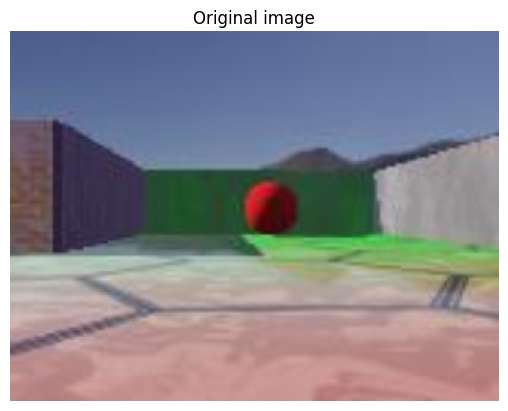

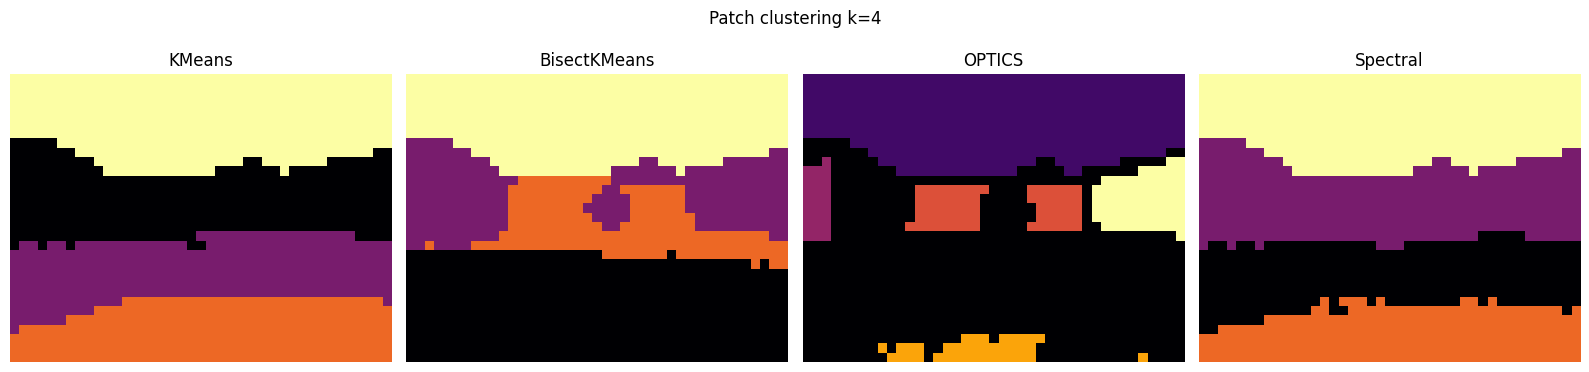

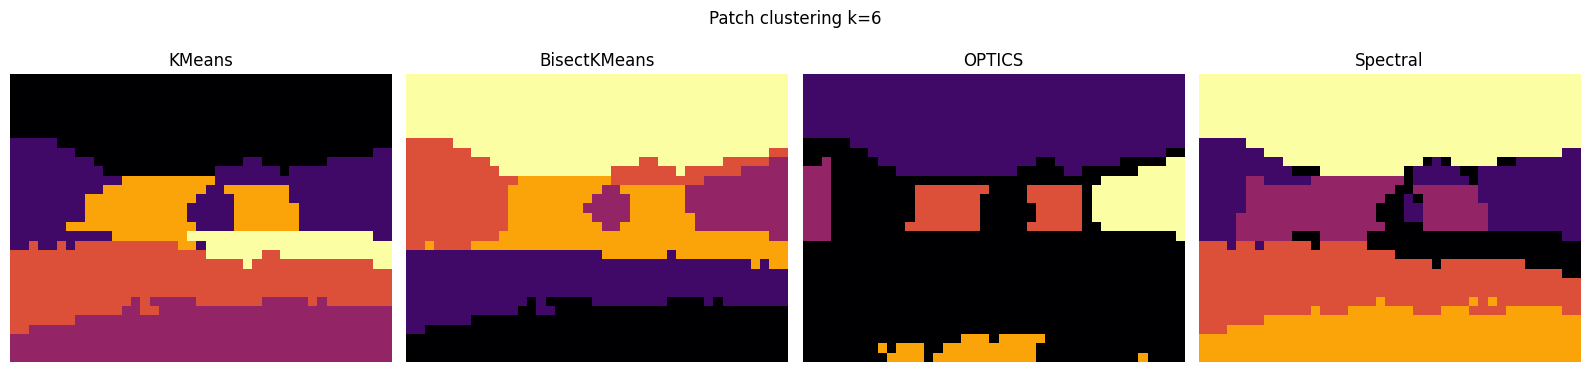

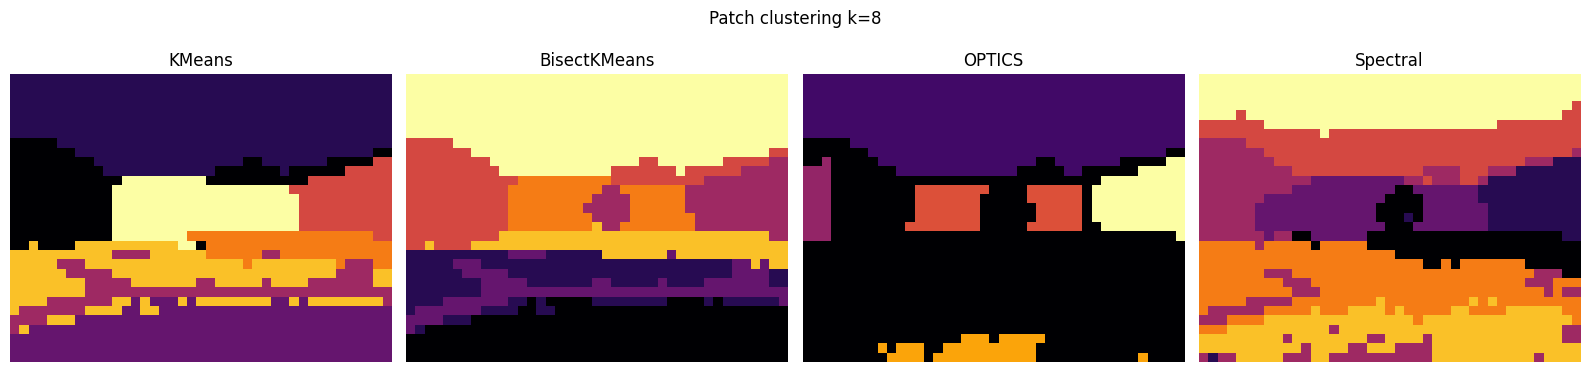

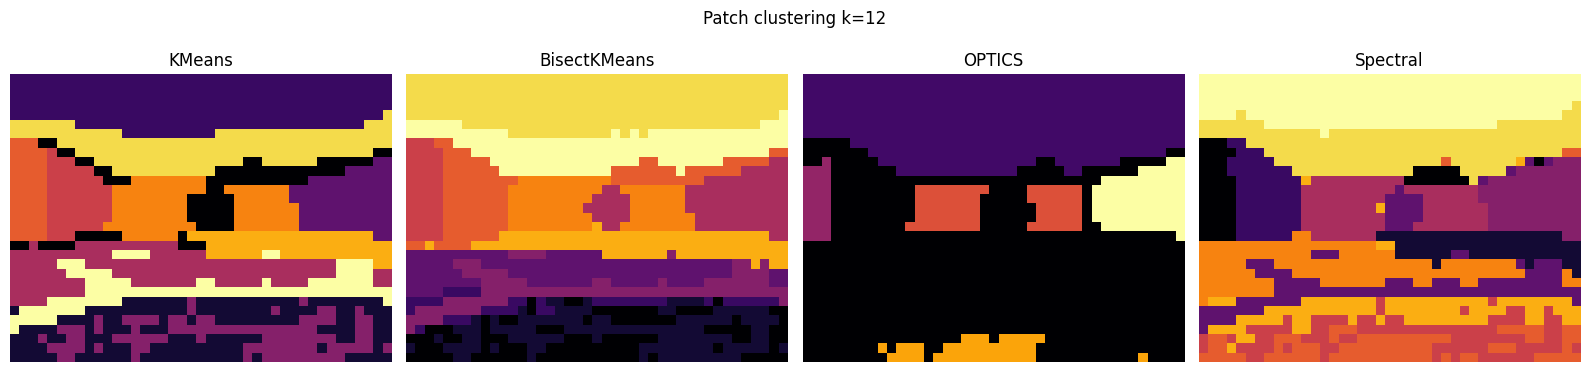

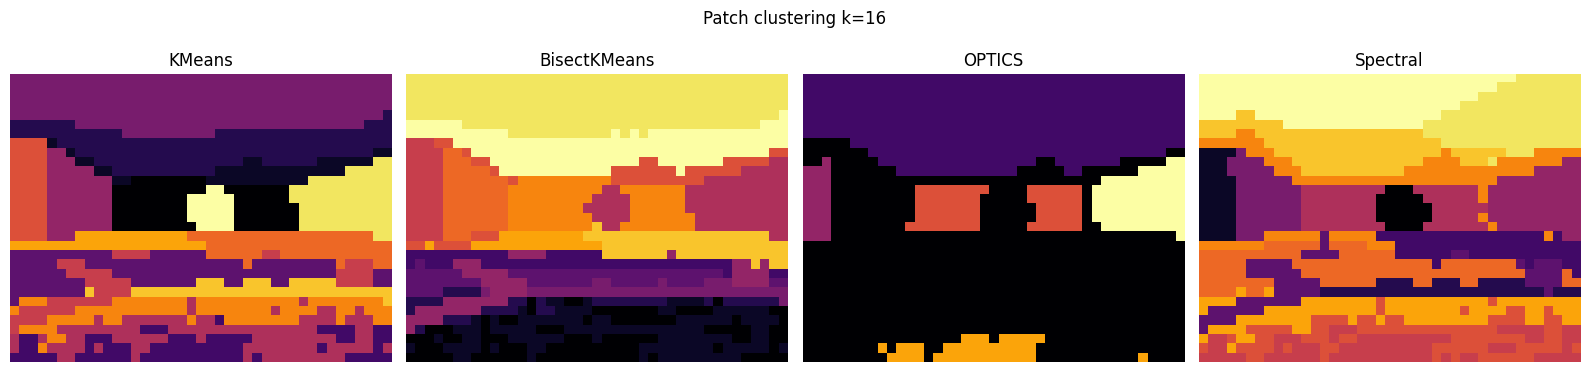

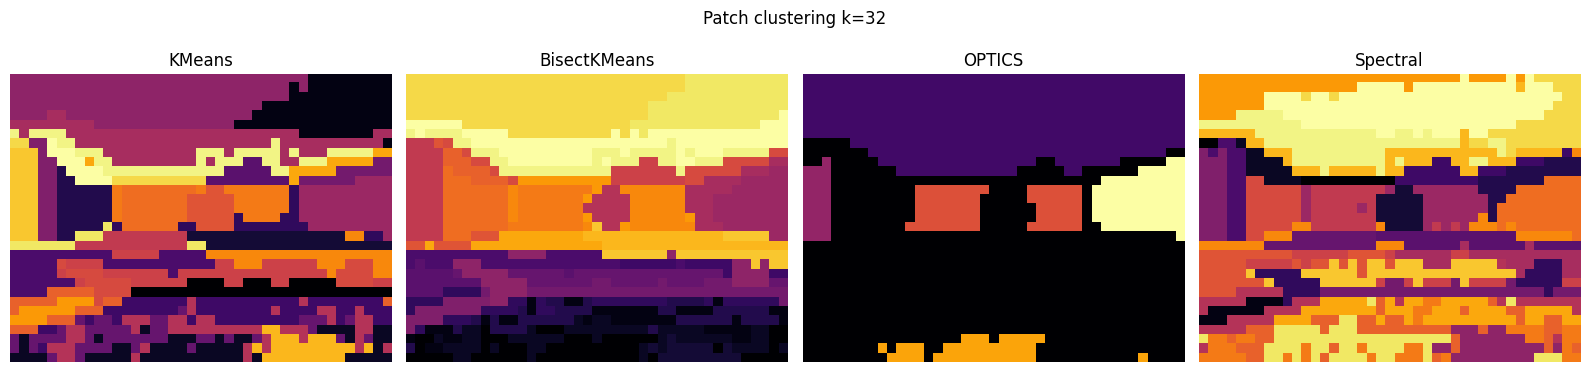

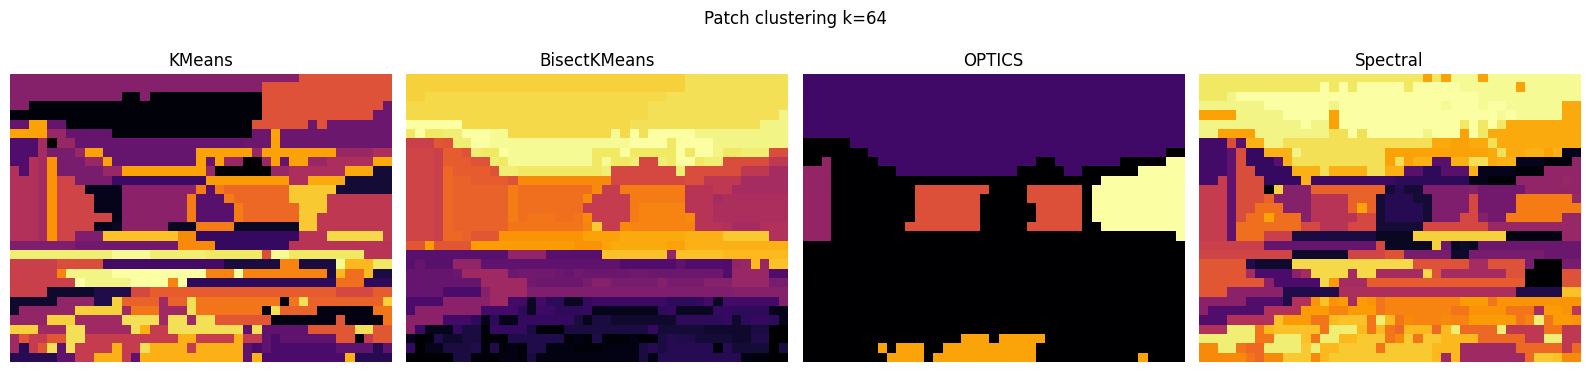

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, BisectingKMeans, SpectralClustering, OPTICS

with torch.no_grad():
    images = images.to(device)
    tokens = model.forward_features(images)

# use first image only
patches = tokens[0, dummy_tokens:, :]          # [N, D]
patches = F.normalize(patches, dim=-1)
feature_reshaped = patches.cpu().numpy()       # [N, D]

h, w = grid_size  # (31, 41)
assert feature_reshaped.shape[0] == h * w

# renormalize image and show it
img = images[0].cpu().permute(1, 2, 0).numpy()  # [H, W, C]
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis('off')
plt.show()

# --- clustering over k ---
n_labels = [4, 6, 8, 12, 16, 32, 64,]

for k in n_labels:
    kmeans       = KMeans(n_clusters=k, random_state=0, n_init=100).fit(feature_reshaped)
    bisect_means = BisectingKMeans(n_clusters=k, random_state=0, n_init=5).fit(feature_reshaped)
    optics       = OPTICS(min_samples=20).fit(feature_reshaped)
    spectral     = SpectralClustering(n_clusters=k, assign_labels='cluster_qr', random_state=0).fit(feature_reshaped)

    imgs = {
        'KMeans':        kmeans.labels_.reshape(h, w),
        'BisectKMeans':  bisect_means.labels_.reshape(h, w),
        'OPTICS':        optics.labels_.reshape(h, w),
        'Spectral':      spectral.labels_.reshape(h, w),
    }


    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (title, img) in zip(axs, imgs.items()):
        ax.imshow(img, cmap='inferno')
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle(f'Patch clustering k={k}')
    plt.tight_layout()
    plt.show()